# Stage 6c(b) diagnostic: ssp370-lowNTCF ingestion check

Companion notebook for `scripts/6c_ood_scenario_diagnostic.py`. Visually confirms the new
OOD scenario (AerChemMIP's `ssp370-lowNTCF`, via RCMIP - see `scripts/6c_ood_scenario_ssp370_lowntcf.py`
for citations) is ingested correctly before trusting any NRMSE numbers built on it: per-agent
emissions continuity across the 1750-2023 historical / 2024-2100 future boundary, the resulting
simulated GMST trajectory, and the baseline emulator's fit against that simulated truth.

This check exists because a real bug was found while building it: the new scenario's future
years were fed to `simulate_targets_gmst` as real calendar years (2024, 2025, ...) instead of
the 0-based relative index every other scenario in this codebase uses, which defeated the
historical-context rebasing and silently created a huge fake gap in the simulation's internal
time axis. Fixed in `build_new_scenario_features` (see its docstring). The boundary-continuity
check below is a direct, human-checkable cross-validation of that fix, independent of it.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('data/SI_results/ood_scenario/ssp370_lowntcf_diagnostic.pkl', 'rb') as f:
    d = pickle.load(f)

agents = d['agents']
print('agents:', agents)
print('historical:', d['years_hist'][0], '-', d['years_hist'][-1], f"(n={len(d['years_hist'])})")
print('future:', d['years_curr'][0], '-', d['years_curr'][-1], f"(n={len(d['years_curr'])})")
print('boundary gap (years):', d['years_curr'][0] - d['years_hist'][-1], '(should be 1)')

agents: ['CO2', 'CH4', 'N2O', 'Sulfur', 'BC']
historical: 1750 - 2023 (n=274)
future: 2024 - 2100 (n=77)
boundary gap (years): 1 (should be 1)


## 1. Per-agent emissions continuity at the historical/future boundary

Each panel shows the full 1750-2100 emissions trajectory for one agent, with historical (this
repo's own calibrated record) and the new RCMIP-sourced future segment in different colors. A
correct ingestion shows a single continuous curve with no jump, gap, or overlap at 2023->2024 -
the mitigation-driven divergence from baseline SSP3-7.0 should appear as a *gradual* bend in the
curve over the following decades, not a discontinuity at the boundary itself.

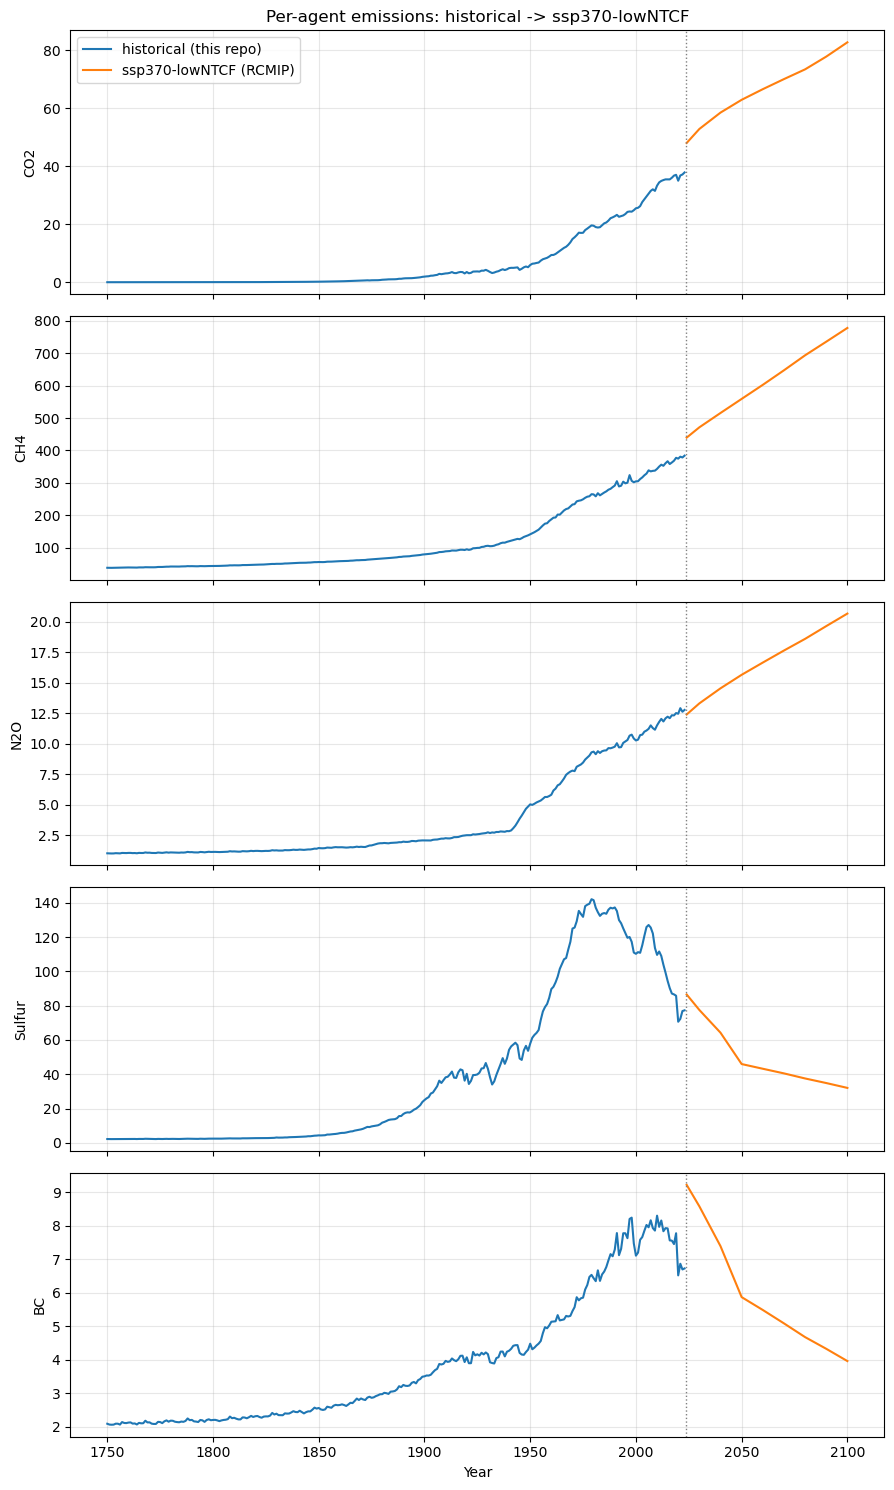

In [2]:
fig, axes = plt.subplots(len(agents), 1, figsize=(9, 3 * len(agents)), sharex=True)
for ax, a in zip(axes, agents):
    ax.plot(d['years_hist'], d['emis_hist_dict'][a], color='tab:blue', lw=1.5, label='historical (this repo)')
    ax.plot(d['years_curr'], d['emis_curr_dict'][a], color='tab:orange', lw=1.5, label='ssp370-lowNTCF (RCMIP)')
    ax.axvline(d['years_hist'][-1] + 0.5, color='gray', ls=':', lw=1)
    ax.set_ylabel(a)
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper left')
axes[-1].set_xlabel('Year')
axes[0].set_title('Per-agent emissions: historical -> ssp370-lowNTCF')
plt.tight_layout()
plt.show()

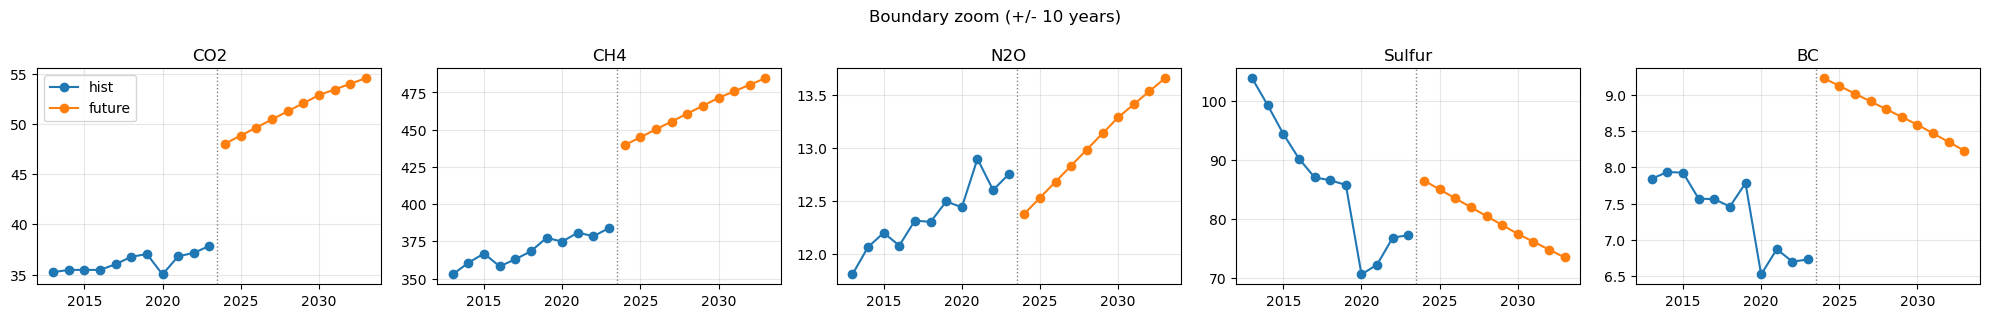

In [3]:
# Zoomed view around the boundary (10 years each side) - the clearest single check for a break
fig, axes = plt.subplots(1, len(agents), figsize=(4 * len(agents), 3.2))
boundary = d['years_hist'][-1]
for ax, a in zip(axes, agents):
    hist_mask = d['years_hist'] >= boundary - 10
    curr_mask = d['years_curr'] <= boundary + 10
    ax.plot(d['years_hist'][hist_mask], d['emis_hist_dict'][a][hist_mask], 'o-', color='tab:blue', label='hist')
    ax.plot(d['years_curr'][curr_mask], d['emis_curr_dict'][a][curr_mask], 'o-', color='tab:orange', label='future')
    ax.axvline(boundary + 0.5, color='gray', ls=':', lw=1)
    ax.set_title(a)
    ax.grid(alpha=0.3)
axes[0].legend()
plt.suptitle('Boundary zoom (+/- 10 years)')
plt.tight_layout()
plt.show()

## 2. Simulated GMST, 1750-2100

One continuous SCM run (`mode='FaIR'`) on the full concatenated emissions series - not sliced
the way the evaluation script's `simulate_targets_gmst` call is, so this is a direct physical
sanity check independent of the feature-construction code path.

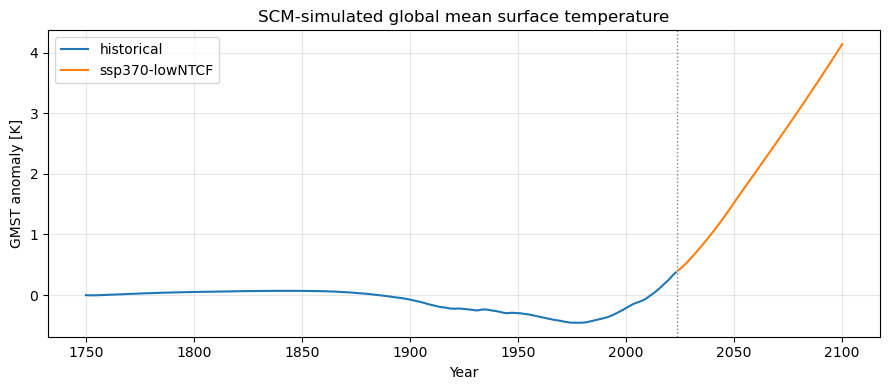

GMST range: [-0.456, 4.137] K


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
n_hist = len(d['years_hist'])
ax.plot(d['years_full'][:n_hist], d['gmst_full'][:n_hist], color='tab:blue', lw=1.5, label='historical')
ax.plot(d['years_full'][n_hist:], d['gmst_full'][n_hist:], color='tab:orange', lw=1.5, label='ssp370-lowNTCF')
ax.axvline(d['years_hist'][-1] + 0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('Year')
ax.set_ylabel('GMST anomaly [K]')
ax.set_title('SCM-simulated global mean surface temperature')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"GMST range: [{d['gmst_full'].min():.3f}, {d['gmst_full'].max():.3f}] K")

## 3. Baseline emulator vs. simulated truth on the new scenario

The baseline emulator (freshly, deterministically retrained on Tier 1, matching this repo's
usual convention) evaluated on `ssp370-lowNTCF`'s own (correctly historical-prepended) features.
This is the genuinely-validated half of Stage 6c(b)'s result - the "optimized" multi-agent
emulator's own number is still blocked on a separate, unrelated reconstruction-validation
mismatch (see REVISIONS.md Session Log) and is not shown here.

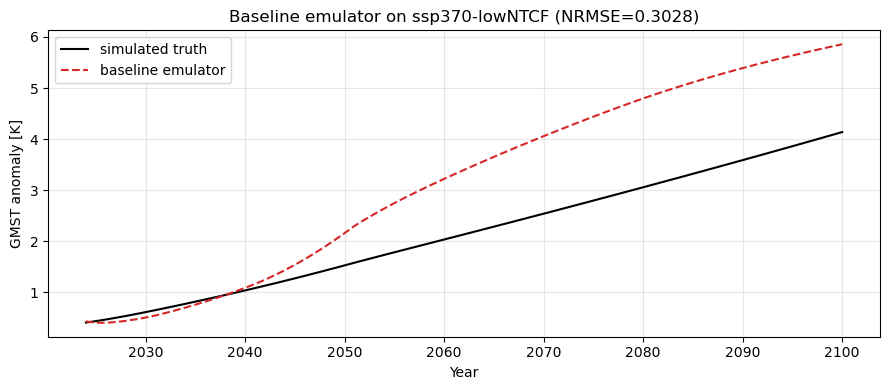

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d['years_feat'], d['baseline_truth'], color='k', lw=1.5, label='simulated truth')
ax.plot(d['years_feat'], d['baseline_pred'], color='tab:red', ls='--', lw=1.5, label='baseline emulator')
ax.set_xlabel('Year')
ax.set_ylabel('GMST anomaly [K]')
ax.set_title(f"Baseline emulator on ssp370-lowNTCF (NRMSE={d['baseline_nrmse']:.4f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()